now here in this notebook we are going to be solving a problem with the train.csv file using logistic regression,decision trees and random forest 

question 1:what problem will i wish to solve for better understanding
business problem where the goal is to predict the survival rate of passengers 

In [27]:
#importing packages
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve)
from sklearn.inspection import permutation_importance
from sklearn.metrics import classification_report



In [58]:
#load dataset
df=pd.read_csv("train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [59]:
#step 1, which factors increase survival
features=['Pclass','Sex', 'Age','Fare']
target = 'Survived'

df = df[features + [target]]
df['Age']=df['Age'].fillna(df['Age'].median())
df['Sex']=df['Sex'].map({
    'male':0,
    'female':1
})
X=df[['Pclass','Age','Sex','Fare']]
y=df['Survived']

#training 

from sklearn.linear_model import LogisticRegression

model=LogisticRegression(max_iter=1000)
model.fit(X,y)

coefficients=pd.DataFrame({
    "features":X.columns,
    "weights":model.coef_[0]
})
print(coefficients)

#survival score
passenger=X.iloc[[0]]

print(passenger)

score = (model.intercept_[0] + (passenger * model.coef_[0]).sum(axis=1))
print(score)

probability=1/(1+np.exp(-score))
print("probability : " ,probability)


  features   weights
0   Pclass -1.115618
1      Age -0.032471
2      Sex  2.513094
3     Fare  0.000819
   Pclass   Age  Sex  Fare
0       3  22.0    0  7.25
0   -2.077867
dtype: float64
probability :  0    0.111267
dtype: float64


In [60]:
#can the model explain survival

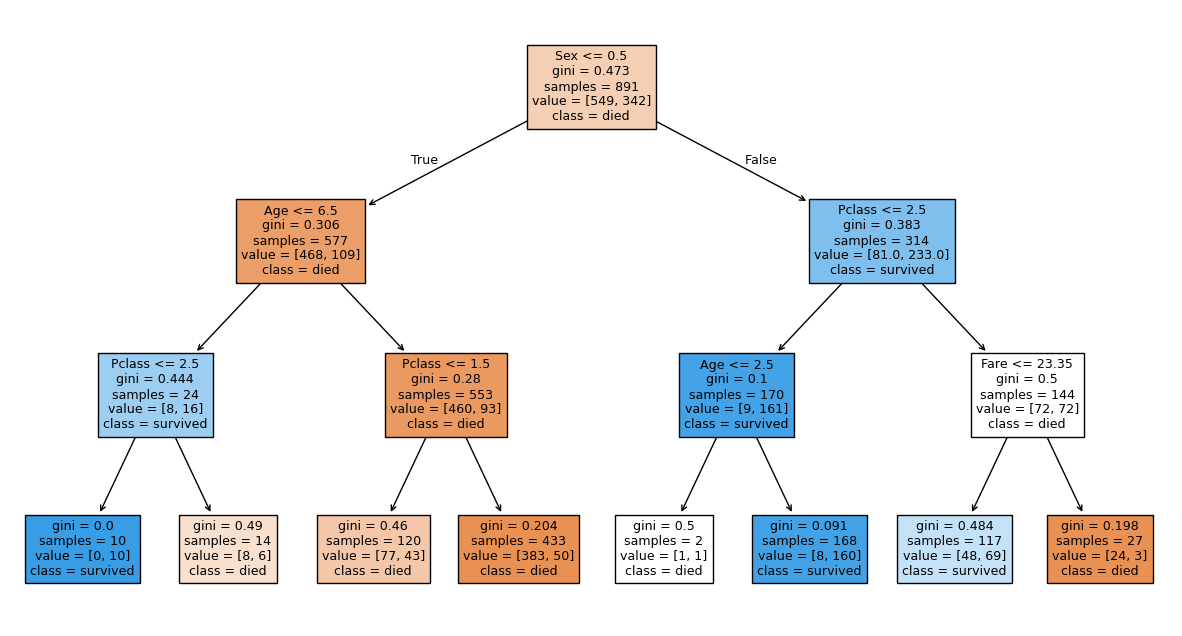

|--- Sex <= 0.50
|   |--- Age <= 6.50
|   |   |--- Pclass <= 2.50
|   |   |   |--- class: 1
|   |   |--- Pclass >  2.50
|   |   |   |--- class: 0
|   |--- Age >  6.50
|   |   |--- Pclass <= 1.50
|   |   |   |--- class: 0
|   |   |--- Pclass >  1.50
|   |   |   |--- class: 0
|--- Sex >  0.50
|   |--- Pclass <= 2.50
|   |   |--- Age <= 2.50
|   |   |   |--- class: 0
|   |   |--- Age >  2.50
|   |   |   |--- class: 1
|   |--- Pclass >  2.50
|   |   |--- Fare <= 23.35
|   |   |   |--- class: 1
|   |   |--- Fare >  23.35
|   |   |   |--- class: 0



,Feature,Importance
2,Sex,0.645450
0,Pclass,0.238913
1,Age,0.063497
3,Fare,0.052140


In [64]:
from sklearn.tree import DecisionTreeClassifier

tree=DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

tree.fit(X,y)

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15,8))

plot_tree(
    tree,
    feature_names=X.columns,
    class_names=['died','survived'],
    filled=True
)
plt.show()

from sklearn.tree import export_text

rules = export_text(
    tree,
    feature_names=list(X.columns)
)

print(rules)

tree.feature_importances_
pd.DataFrame({
    'Feature': X.columns,
    'Importance': tree.feature_importances_
}).sort_values('Importance', ascending=False)

In [62]:
#what if i ask more captains

In [65]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X, y)
import pandas as pd

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

print(
    importance.sort_values(
        'Importance',
        ascending=False
    )
)

  Feature  Importance
3    Fare    0.339329
1     Age    0.281196
2     Sex    0.280151
0  Pclass    0.099325
